In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
paultimothymooney_chest_xray_pneumonia_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

print('Data source import complete.')


# 🫁 Updated Hybrid Framework for Pneumonia Detection in Chest X-Ray Images

**Architecture Overview:**
- **Branch 1:** ShuffleNetV2 + ECA (Efficient Channel Attention) — lightweight, fine-grained local features
- **Branch 2:** EfficientNet-B0 + CBAM (Convolutional Block Attention Module) — global semantic + spatial features
- **CBAF Module:** Cross-Branch Attention Fusion — attention-gated fusion of the two branches, replacing naive concatenation
- **LAMR Module:** Lesion-Aware Multi-scale Refinement (inspired by multi-scale nodule detection)
- **Grad-CAM:** Interpretability visualization for clinical reliability

**Ablation-ready:** every component above (ECA, CBAM, CBAF, LAMR, and either branch) can be switched on/off via flags on `HybridPneumoniaNet`. §16 trains and evaluates every combination and reports the marginal contribution of removing LAMR and CBAF specifically, as well as ECA/CBAM — not just a comparison of whole architectures.

> Dataset: [Chest X-ray Pneumonia (Kaggle)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)

## 1. Install & Import Dependencies

In [ ]:
# ── Install any missing packages ──────────────────────────────────────────────
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pip_install('timm')          # pretrained EfficientNet-B0 / ShuffleNetV2
pip_install('grad-cam')      # pytorch-grad-cam
pip_install('albumentations') # augmentation
print('All packages ready.')

All packages ready.


In [ ]:
# ── Standard imports ──────────────────────────────────────────────────────────
import os, random, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as tv_models
import timm

# ── Sklearn metrics ───────────────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

# ── Grad-CAM ──────────────────────────────────────────────────────────────────
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── Albumentations ────────────────────────────────────────────────────────────
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 2. Configuration

In [ ]:
# ── Hyper-parameters & paths ─────────────────────────────────────────────────
class CFG:
    # ── Dataset paths (Kaggle environment) ────────────────────────────────────
    DATA_DIR   = Path('/kaggle/input/chest-xray-pneumonia/chest_xray')
    TRAIN_DIR  = DATA_DIR / 'train'
    VAL_DIR    = DATA_DIR / 'val'
    TEST_DIR   = DATA_DIR / 'test'

    # ── Image ─────────────────────────────────────────────────────────────────
    IMG_SIZE   = 224          # both branches expect 224×224
    IN_CHANS   = 3

    # ── Training ──────────────────────────────────────────────────────────────
    BATCH_SIZE = 32
    EPOCHS     = 30
    ABLATION_EPOCHS = 10   # shorter budget per ablation variant (8 variants total)
    LR         = 3e-4
    WEIGHT_DECAY = 1e-4
    NUM_WORKERS  = 4

    # ── Model ─────────────────────────────────────────────────────────────────
    NUM_CLASSES   = 2          # NORMAL / PNEUMONIA
    FUSION_DIM    = 256        # after projection
    LAMR_CHANNELS = 256        # LAMR internal channels

    # ── Class labels ──────────────────────────────────────────────────────────
    CLASSES = ['NORMAL', 'PNEUMONIA']

    # ── Checkpoint ────────────────────────────────────────────────────────────
    CKPT_PATH = '/kaggle/working/best_model.pth'

cfg = CFG()
print('Configuration loaded.')

Configuration loaded.


## 3. Dataset & Data Augmentation

In [ ]:
# ── Albumentations transforms ──────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_train_transforms():
    return A.Compose([
        A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=15, border_mode=0, p=0.5),
        A.GaussNoise(p=0.3),
        A.CoarseDropout(num_holes_range=(1, 8), hole_height_range=(8, 16), hole_width_range=(8, 16), p=0.3),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

def get_val_transforms():
    return A.Compose([
        A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])


# ── Dataset that verifies image integrity and skips corrupted files ───────────
class ChestXRayDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        self.label_map = {cls: i for i, cls in enumerate(cfg.CLASSES)}

        if not self.root_dir.exists():
            raise FileNotFoundError(f'Directory not found: {self.root_dir}')

        bad_files = 0
        for cls in cfg.CLASSES:
            cls_dir = self.root_dir / cls
            if not cls_dir.exists():
                print(f'[WARNING] Missing folder: {cls_dir}')
                continue
            count = 0
            for img_path in cls_dir.rglob('*'):
                if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
                    continue
                try:
                    with Image.open(img_path) as img:
                        img.verify()
                    self.samples.append((img_path, self.label_map[cls]))
                    count += 1
                except Exception:
                    bad_files += 1
            print(f'  {cls}: {count} valid images')

        print(f'Loaded {len(self.samples)} images from {self.root_dir}  (skipped {bad_files} corrupted)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = np.array(Image.open(img_path).convert('RGB'))
        except Exception:
            # fallback if an image becomes unreadable at read time
            return self.__getitem__(np.random.randint(len(self.samples)))
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label


# ── Build datasets & loaders ───────────────────────────────────────────────────
print('Building datasets...')
train_dataset = ChestXRayDataset(os.path.join(output_path, 'train'), transform=get_train_transforms())
val_dataset   = ChestXRayDataset(os.path.join(output_path, 'val'),   transform=get_val_transforms())
test_dataset  = ChestXRayDataset(os.path.join(output_path, 'test'),  transform=get_val_transforms())

assert len(train_dataset) > 0, 'Training dataset is empty!'
assert len(val_dataset)   > 0, 'Validation dataset is empty!'
assert len(test_dataset)  > 0, 'Test dataset is empty!'

print('\nDataset sizes')
print(f'  Train: {len(train_dataset)}')
print(f'  Val  : {len(val_dataset)}')
print(f'  Test : {len(test_dataset)}')

# drop_last=True avoids a final batch of size 1, which would crash BatchNorm1d
# layers in the model heads during training (they need >1 sample per channel).
train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True,
                           num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=cfg.BATCH_SIZE, shuffle=False,
                           num_workers=cfg.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=cfg.BATCH_SIZE, shuffle=False,
                           num_workers=cfg.NUM_WORKERS, pin_memory=True)

# ── Class distribution (also used later for class-weighted loss) ─────────────
train_labels = [label for _, label in train_dataset.samples]
unique, counts = np.unique(train_labels, return_counts=True)

print('\nTraining class distribution')
for u, c in zip(unique, counts):
    print(f'  {cfg.CLASSES[u]}: {c}')

Building datasets...
  NORMAL: 1108 valid images
  PNEUMONIA: 2991 valid images
Loaded 4099 images from /kaggle/working/chest_xray_split/train  (skipped 0 corrupted)
  NORMAL: 237 valid images
  PNEUMONIA: 641 valid images
Loaded 878 images from /kaggle/working/chest_xray_split/val  (skipped 0 corrupted)
  NORMAL: 238 valid images
  PNEUMONIA: 641 valid images
Loaded 879 images from /kaggle/working/chest_xray_split/test  (skipped 0 corrupted)

Dataset sizes
  Train: 4099
  Val  : 878
  Test : 879

Training class distribution
  NORMAL: 1108
  PNEUMONIA: 2991


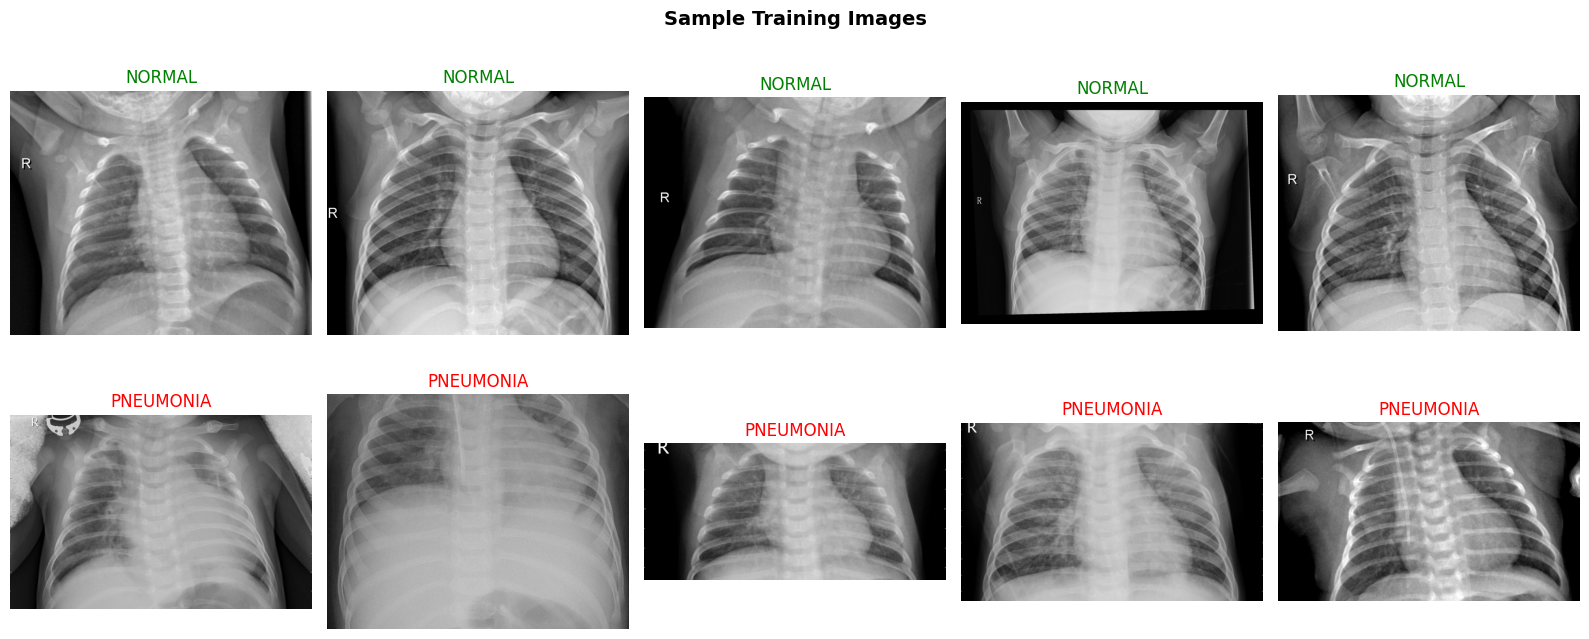

In [ ]:
# ── Visualise sample images ───────────────────────────────────────────────────
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Training Images', fontsize=14, fontweight='bold')

for cls_idx, cls_name in enumerate(cfg.CLASSES):
    cls_samples = [(p, l) for p, l in train_dataset.samples if l == cls_idx]
    for i in range(5):
        img_path, _ = random.choice(cls_samples)
        img = np.array(Image.open(img_path).convert('RGB'))
        axes[cls_idx, i].imshow(img, cmap='gray' if img.mean(axis=2).std() < 10 else None)
        axes[cls_idx, i].set_title(cls_name, color='green' if cls_idx == 0 else 'red')
        axes[cls_idx, i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=150)
plt.show()

## 4. Attention Modules: ECA, CBAM

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  ECA — Efficient Channel Attention                                          ║
# ║  Wang et al. (2020) CVPR                                                    ║
# ║  Replaces FC bottleneck with a lightweight 1-D convolution across channels  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
class ECA(nn.Module):
    """
    Efficient Channel Attention.
    Kernel size k is adaptively determined from the number of channels C.
    """
    def __init__(self, channels: int, gamma: int = 2, b: int = 1):
        super().__init__()
        # Adaptive kernel size
        t  = int(abs(math.log2(channels) / gamma + b / gamma))
        k  = t if t % 2 else t + 1
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=k,
                                  padding=k // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W)
        y = self.avg_pool(x)            # (B, C, 1, 1)
        y = y.squeeze(-1).transpose(-1, -2)  # (B, 1, C)
        y = self.conv(y)                # (B, 1, C)
        y = y.transpose(-1, -2).unsqueeze(-1)  # (B, C, 1, 1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CBAM — Convolutional Block Attention Module                                ║
# ║  Woo et al. (2018) ECCV                                                     ║
# ║  Sequential channel attention → spatial attention                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
class ChannelAttention(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        reduced = max(channels // reduction, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = self.shared_mlp(self.avg_pool(x))
        max_out = self.shared_mlp(self.max_pool(x))
        out     = self.sigmoid(avg_out + max_out)
        return x * out.unsqueeze(-1).unsqueeze(-1)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size,
                                 padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True).values
        out     = torch.cat([avg_out, max_out], dim=1)
        out     = self.sigmoid(self.conv(out))
        return x * out


class CBAM(nn.Module):
    """Channel → Spatial attention block."""
    def __init__(self, channels: int, reduction: int = 16, spatial_k: int = 7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(spatial_k)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.ca(x)
        x = self.sa(x)
        return x


print('ECA and CBAM modules defined.')

ECA and CBAM modules defined.


## 5. LAMR — Lesion-Aware Multi-scale Refinement Module

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  LAMR — Lesion-Aware Multi-scale Refinement                                 ║
# ║                                                                              ║
# ║  Inspired by the HPFF (Hierarchical Progressive Feature Fusion) and GCSAM   ║
# ║  ideas in Li et al. (2025) for lung nodule detection.                        ║
# ║                                                                              ║
# ║  Three parallel convolution streams (1×1, 3×3, 5×5) capture lesion          ║
# ║  patterns at different receptive fields, then a channel-wise                 ║
# ║  attention gate produces a lesion-sensitive mask to refine the fused         ║
# ║  feature map.                                                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
class LAMRBlock(nn.Module):
    """
    Lesion-Aware Multi-scale Refinement block.

    Args:
        in_channels  : number of input channels (= fusion feature size after projection)
        out_channels : number of output channels
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        mid = out_channels // 4  # internal bottleneck

        # ── Multi-scale parallel branches ──────────────────────────────────────
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, mid, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, mid, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True),
            nn.Conv2d(mid, mid, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        self.branch5 = nn.Sequential(
            nn.Conv2d(in_channels, mid, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True),
            nn.Conv2d(mid, mid, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        # ── Global context (avg-pool) branch ───────────────────────────────────
        self.branch_global = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, mid, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )

        concat_ch = mid * 4          # 4 branches

        # ── Projection to out_channels ─────────────────────────────────────────
        self.proj = nn.Sequential(
            nn.Conv2d(concat_ch, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )

        # ── Lesion-sensitive attention gate (channel-wise) ─────────────────────
        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels, out_channels // 4, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels // 4, out_channels, kernel_size=1),
            nn.Sigmoid()
        )

        # ── Residual shortcut (adjust channels if needed) ──────────────────────
        self.shortcut = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape

        b1 = self.branch1(x)                     # (B, mid, H, W)
        b3 = self.branch3(x)                     # (B, mid, H, W)
        b5 = self.branch5(x)                     # (B, mid, H, W)
        bg = self.branch_global(x).expand(B, -1, H, W)  # broadcast

        ms = torch.cat([b1, b3, b5, bg], dim=1)  # (B, 4*mid, H, W)
        ms = self.proj(ms)                        # (B, out_channels, H, W)

        # ── Apply lesion attention gate ────────────────────────────────────────
        gate_w = self.gate(ms)                    # (B, out_channels, 1, 1)
        ms     = ms * gate_w                      # element-wise scale

        return ms + self.shortcut(x)              # residual addition


print('LAMR block defined.')

LAMR block defined.


## 5b. CBAF — Cross-Branch Attention Fusion Module


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CBAF — Cross-Branch Attention Fusion                                       ║
# ║                                                                              ║
# ║  Naive fusion just concatenates the ShuffleNetV2+ECA vector (f1) and the    ║
# ║  EfficientNet-B0+CBAM vector (f2). CBAF instead lets each branch's output   ║
# ║  be *gated* by a joint context of both branches before concatenation, so    ║
# ║  the network can down-weight a branch when its features are uninformative  ║
# ║  for a given sample (e.g. rely more on the global/semantic branch when      ║
# ║  local texture is ambiguous, and vice-versa).                               ║
# ║                                                                              ║
# ║  Output shape is identical to naive concatenation (B, 2*dim), so CBAF can   ║
# ║  be toggled on/off without touching any other part of the network — this    ║
# ║  is exactly what makes it possible to ablate cleanly.                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
class CBAF(nn.Module):
    """
    Cross-Branch Attention Fusion.

    Args:
        dim       : feature dimension of EACH branch (proj_dim)
        reduction : bottleneck reduction ratio for the gating MLPs
    """
    def __init__(self, dim: int, reduction: int = 4):
        super().__init__()
        hidden = max(dim // reduction, 8)

        # Gate for branch-1 (ShuffleNetV2+ECA), conditioned on BOTH branches
        self.gate1 = nn.Sequential(
            nn.Linear(dim * 2, hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, dim), nn.Sigmoid()
        )
        # Gate for branch-2 (EfficientNet-B0+CBAM), conditioned on BOTH branches
        self.gate2 = nn.Sequential(
            nn.Linear(dim * 2, hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, dim), nn.Sigmoid()
        )

    def forward(self, f1: torch.Tensor, f2: torch.Tensor) -> torch.Tensor:
        # f1, f2: (B, dim)
        joint = torch.cat([f1, f2], dim=1)     # (B, 2*dim) — cross-branch context
        g1    = self.gate1(joint)              # (B, dim)  — how much of f1 to keep
        g2    = self.gate2(joint)              # (B, dim)  — how much of f2 to keep
        f1_att = f1 * g1
        f2_att = f2 * g2
        return torch.cat([f1_att, f2_att], dim=1)   # (B, 2*dim) — same shape as naive concat


print('CBAF module defined.')


CBAF module defined.


## 6. Branch Backbones: ShuffleNetV2 + ECA and EfficientNet-B0 + CBAM

In [ ]:
# ============================================================
# Branch 1: ShuffleNetV2 + ECA  (torchvision backbone)
# ============================================================
class ShuffleNetV2_ECA(nn.Module):
    def __init__(self, proj_dim=256, pretrained=True, use_eca=True):
        super().__init__()
        weights = tv_models.ShuffleNet_V2_X1_0_Weights.DEFAULT if pretrained else None
        base = tv_models.shufflenet_v2_x1_0(weights=weights)
        self.backbone = nn.Sequential(base.conv1, base.maxpool, base.stage2, base.stage3, base.stage4, base.conv5)
        feat_dim = 1024
        self.eca  = ECA(channels=feat_dim) if use_eca else nn.Identity()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(nn.Flatten(), nn.Linear(feat_dim, proj_dim), nn.BatchNorm1d(proj_dim), nn.ReLU(inplace=True))
    def forward(self, x):
        x = self.backbone(x); x = self.eca(x); x = self.pool(x); return self.proj(x)


    # def get_last_conv(self):
    #     for m in reversed(list(self.backbone.modules())):
    #         if isinstance(m, nn.Conv2d):
    #             return m
    #     return None


# ============================================================
# Branch 2: EfficientNet-B0 + CBAM  (torchvision backbone)
# ============================================================
class EfficientNetB0_CBAM(nn.Module):
    def __init__(self, proj_dim=256, pretrained=True, use_cbam=True):
        super().__init__()
        weights = tv_models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        base = tv_models.efficientnet_b0(weights=weights)
        self.backbone = base.features
        feat_dim = 1280
        self.cbam = CBAM(channels=feat_dim) if use_cbam else nn.Identity()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(nn.Flatten(), nn.Linear(feat_dim, proj_dim), nn.BatchNorm1d(proj_dim), nn.ReLU(inplace=True))
    def forward(self, x):
        x = self.backbone(x); x = self.cbam(x); x = self.pool(x); return self.proj(x)

    def get_last_conv(self):
        for m in reversed(list(self.backbone.modules())):
            if isinstance(m, nn.Conv2d):
                return m
        return None


# ============================================================
# Sanity-check both branches
# ============================================================
dummy = torch.zeros(2, 3, 224, 224)

b1 = ShuffleNetV2_ECA(proj_dim=256, pretrained=False)
print('ShuffleNetV2-ECA output:', b1(dummy).shape)

b2 = EfficientNetB0_CBAM(proj_dim=256, pretrained=False)
print('EfficientNetB0-CBAM output:', b2(dummy).shape)

ShuffleNetV2-ECA output: torch.Size([2, 256])
EfficientNetB0-CBAM output: torch.Size([2, 256])


## 7. Full Hybrid Model

In [ ]:
class HybridPneumoniaNet(nn.Module):
    """
    Updated Hybrid Framework
    ========================
    Input  → [ShuffleNetV2+ECA] branch  (local, fine-grained)
           → [EfficientNet-B0+CBAM] branch (global, semantic)
    Fused features → spatial reshape → LAMR module → GAP → classifier

    The LAMR module operates on a 2D spatial feature map reconstructed
    from the concatenated 1-D vectors via a learned reshape/expand path,
    mimicking the receptive-field diversity of the HPFF + GCSAM approach.
    """

    def __init__(
        self,
        num_classes  : int = 2,
        proj_dim     : int = 256,
        lamr_channels: int = 256,
        pretrained   : bool = True,
        dropout_p    : float = 0.4
    ):
        super().__init__()

        # ── Two feature branches ──────────────────────────────────────────────
        self.branch_shuffle = ShuffleNetV2_ECA(proj_dim=proj_dim, pretrained=pretrained)
        self.branch_effnet  = EfficientNetB0_CBAM(proj_dim=proj_dim, pretrained=pretrained)

        fused_dim = proj_dim * 2   # concatenation of two branches

        # ── Fusion projection to a square spatial map for LAMR ────────────────
        self.fusion_proj = nn.Sequential(
            nn.Linear(fused_dim, lamr_channels),
            nn.BatchNorm1d(lamr_channels),
            nn.ReLU(inplace=True)
        )
        # Upsample 1×1 → 7×7 feature map for LAMR to act on
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(lamr_channels, lamr_channels, kernel_size=7, stride=1, bias=False),
            nn.BatchNorm2d(lamr_channels),
            nn.ReLU(inplace=True)
        )

        # ── LAMR module ───────────────────────────────────────────────────────
        self.lamr = LAMRBlock(in_channels=lamr_channels, out_channels=lamr_channels)

        # ── Global Average Pool + Classifier ─────────────────────────────────
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.Linear(lamr_channels, lamr_channels // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p / 2),
            nn.Linear(lamr_channels // 2, num_classes)
        )

    def forward(self, x: torch.Tensor):
        # Branch 1: ShuffleNetV2 + ECA
        f1 = self.branch_shuffle(x)           # (B, proj_dim)
        # Branch 2: EfficientNet-B0 + CBAM
        f2 = self.branch_effnet(x)            # (B, proj_dim)

        # ── Feature fusion ────────────────────────────────────────────────────
        fused = torch.cat([f1, f2], dim=1)    # (B, 2*proj_dim)
        fused = self.fusion_proj(fused)        # (B, lamr_channels)

        # ── Reshape to 2D spatial map for LAMR ────────────────────────────────
        fused = fused.unsqueeze(-1).unsqueeze(-1)   # (B, lamr_ch, 1, 1)
        fused = self.upsample(fused)                 # (B, lamr_ch, 7, 7)

        # ── LAMR: multi-scale lesion refinement ───────────────────────────────
        fused = self.lamr(fused)               # (B, lamr_ch, 7, 7)

        # ── Classification ────────────────────────────────────────────────────
        out  = self.gap(fused)                 # (B, lamr_ch, 1, 1)
        out  = self.head(out)                  # (B, num_classes)
        return out


# ── Instantiate & test ────────────────────────────────────────────────────────
model = HybridPneumoniaNet(
    num_classes   = cfg.NUM_CLASSES,
    proj_dim      = cfg.FUSION_DIM,
    lamr_channels = cfg.LAMR_CHANNELS,
    pretrained    = True
).to(DEVICE)

dummy = torch.zeros(2, 3, 224, 224).to(DEVICE)
out   = model(dummy)
print(f'Model output shape: {out.shape}')   # (2, 2)

# ── Parameter count ───────────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters   : {total_params / 1e6:.2f}M')
print(f'Trainable parameters: {train_params / 1e6:.2f}M')

Model output shape: torch.Size([2, 2])
Total parameters   : 9.74M
Trainable parameters: 9.74M


## 8. Loss Function, Optimizer, Scheduler

In [ ]:
# ── Compute class weights to handle imbalance ─────────────────────────────────
class_counts = np.array([counts[0], counts[1]], dtype=np.float32)
class_weights = torch.tensor(
    1.0 / (class_counts / class_counts.sum()), dtype=torch.float32
).to(DEVICE)
print(f'Class weights: {class_weights.cpu().numpy()}')

criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = optim.AdamW(model.parameters(),
                         lr=cfg.LR,
                         weight_decay=cfg.WEIGHT_DECAY)
# ── Cosine annealing with warm restarts ───────────────────────────────────────
scheduler  = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

# ── Mixed precision scaler ────────────────────────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))
print('Criterion / Optimizer / Scheduler ready.')

Class weights: [3.6994584 1.3704447]
Criterion / Optimizer / Scheduler ready.


## 9. Training & Validation Loops

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        preds         = logits.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    for imgs, labels in tqdm(loader, desc='    Val', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        running_loss += loss.item() * imgs.size(0)
        probs         = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds         = logits.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / total
    acc      = correct / total
    auc      = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return avg_loss, acc, auc


print('Training functions defined.')

Training functions defined.


In [ ]:
# ── Training loop ─────────────────────────────────────────────────────────────
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : [], 'val_auc': []
}
best_val_auc = 0.0

for epoch in range(1, cfg.EPOCHS + 1):
    print(f'\nEpoch [{epoch:02d}/{cfg.EPOCHS}]  lr={scheduler.get_last_lr()[0]:.2e}')

    tr_loss, tr_acc = train_one_epoch(model, train_loader,
                                       optimizer, criterion, scaler, DEVICE)
    va_loss, va_acc, va_auc = validate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc' ].append(tr_acc)
    history['val_loss'  ].append(va_loss)
    history['val_acc'   ].append(va_acc)
    history['val_auc'   ].append(va_auc)

    print(f'  Train  loss={tr_loss:.4f}  acc={tr_acc:.4f}')
    print(f'  Val    loss={va_loss:.4f}  acc={va_acc:.4f}  AUC={va_auc:.4f}')

    if va_auc > best_val_auc:
        best_val_auc = va_auc
        torch.save(model.state_dict(), cfg.CKPT_PATH)
        print(f'  ✅ New best model saved  (AUC={best_val_auc:.4f})')

print('\nTraining complete.')


Epoch [01/30]  lr=3.00e-04


  Train:   0%|          | 0/128 [00:00<?, ?it/s]

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

  Train  loss=0.3493  acc=0.8569
  Val    loss=0.1229  acc=0.9567  AUC=0.9931
  ✅ New best model saved  (AUC=0.9931)

Epoch [02/30]  lr=2.93e-04


  Train:   0%|          | 0/128 [00:00<?, ?it/s]

...

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

  Train  loss=0.0467  acc=0.9868
  Val    loss=0.0926  acc=0.9749  AUC=0.9951

Epoch [30/30]  lr=2.84e-06


  Train:   0%|          | 0/128 [00:00<?, ?it/s]

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

  Train  loss=0.0459  acc=0.9885
  Val    loss=0.0928  acc=0.9761  AUC=0.9952

Training complete.


## 10. Training Curves

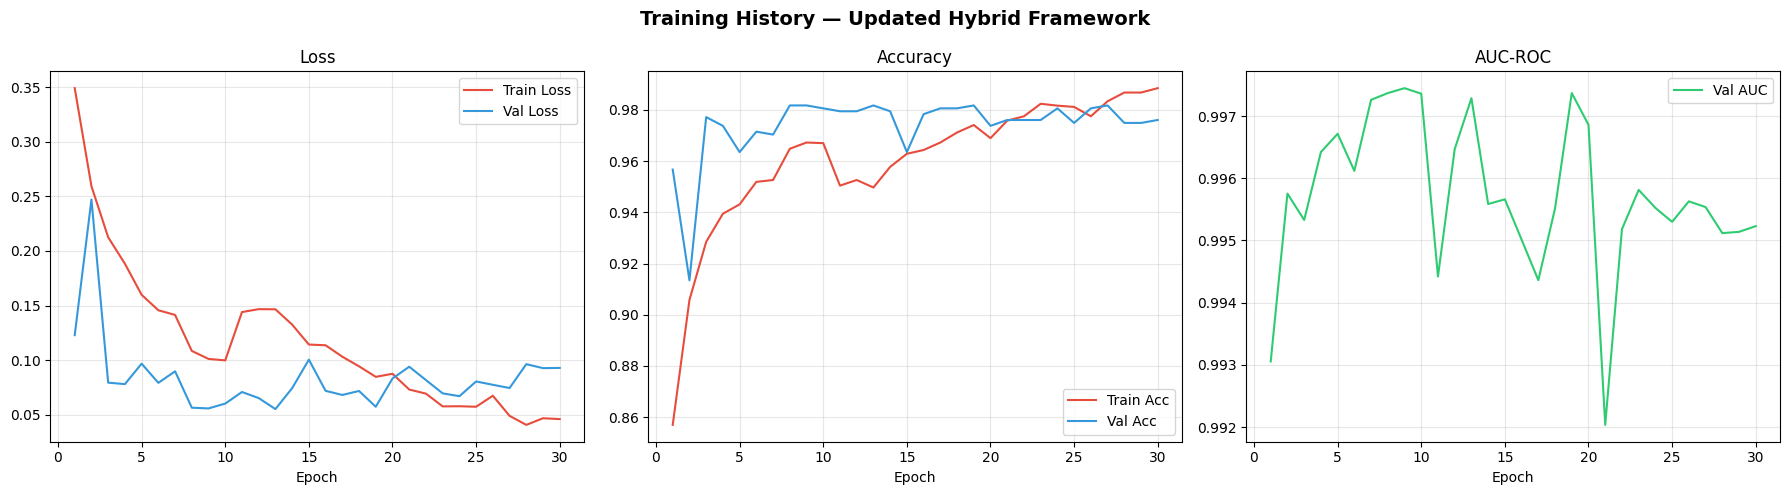

In [ ]:
epochs_range = range(1, cfg.EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — Updated Hybrid Framework', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='#e74c3c')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   color='#3498db')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], label='Train Acc', color='#e74c3c')
axes[1].plot(epochs_range, history['val_acc'],   label='Val Acc',   color='#3498db')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

# AUC
axes[2].plot(epochs_range, history['val_auc'], label='Val AUC', color='#2ecc71')
axes[2].set_title('AUC-ROC'); axes[2].set_xlabel('Epoch'); axes[2].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

## 11. Test Set Evaluation

In [ ]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
model.load_state_dict(torch.load(cfg.CKPT_PATH, map_location=DEVICE))
model.eval()

@torch.no_grad()
def predict(model, loader, device):
    all_preds, all_probs, all_labels = [], [], []
    for imgs, labels in tqdm(loader, desc='  Test', leave=False):
        imgs   = imgs.to(device)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

y_pred, y_prob, y_true = predict(model, test_loader, DEVICE)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
auc  = roc_auc_score(y_true, y_prob)

print('=' * 55)
print('TEST SET PERFORMANCE — Updated Hybrid Framework')
print('=' * 55)
print(f'  Accuracy  : {acc  * 100:.2f}%')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC-ROC   : {auc:.4f}')
print('=' * 55)
print(classification_report(y_true, y_pred, target_names=cfg.CLASSES))

  Test:   0%|          | 0/28 [00:00<?, ?it/s]

TEST SET PERFORMANCE — Updated Hybrid Framework
  Accuracy  : 97.72%
  Precision : 0.9905
  Recall    : 0.9782
  F1-Score  : 0.9843
  AUC-ROC   : 0.9975
              precision    recall  f1-score   support

      NORMAL       0.94      0.97      0.96       238
   PNEUMONIA       0.99      0.98      0.98       641

    accuracy                           0.98       879
   macro avg       0.97      0.98      0.97       879
weighted avg       0.98      0.98      0.98       879



## 12. Confusion Matrix

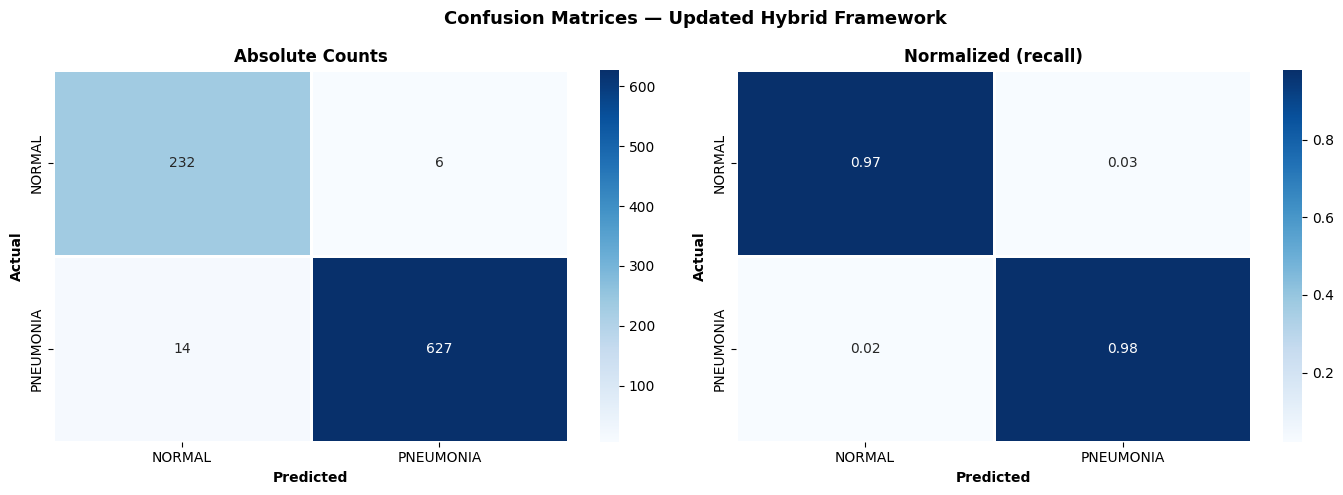

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices — Updated Hybrid Framework', fontsize=13, fontweight='bold')

for ax, norm, title in zip(axes,
                            [None, 'true'],
                            ['Absolute Counts', 'Normalized (recall)']):
    cm_plot = confusion_matrix(y_true, y_pred, normalize=norm)
    fmt = 'd' if norm is None else '.2f'
    sns.heatmap(cm_plot, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=cfg.CLASSES, yticklabels=cfg.CLASSES,
                linewidths=1, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('Actual', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

## 13. ROC Curve

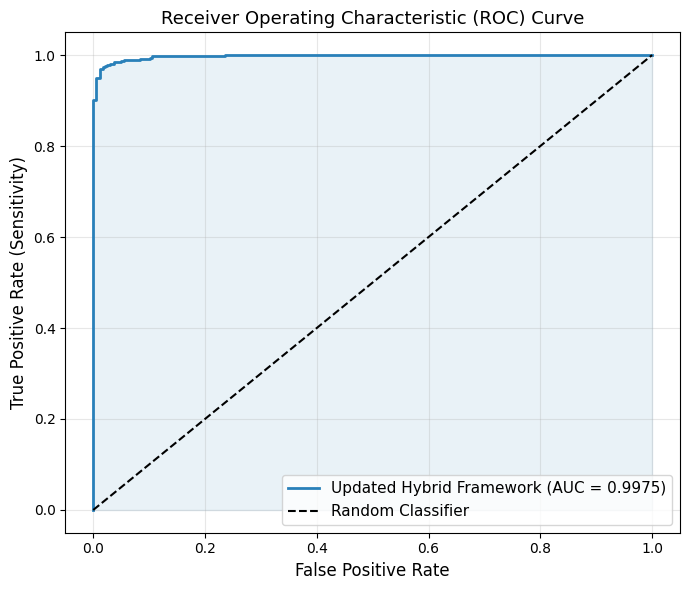

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#2980b9', lw=2,
        label=f'Updated Hybrid Framework (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2980b9')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve.png', dpi=150)
plt.show()

## 14. Performance Radar Chart

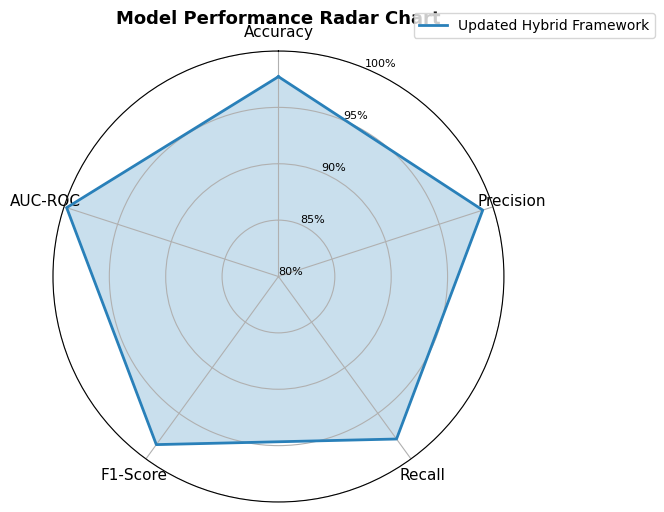

In [ ]:
# ── Radar chart comparing key metrics ────────────────────────────────────────
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values         = [acc * 100, prec * 100, rec * 100, f1 * 100, auc * 100]

N = len(metrics_labels)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]    # close the polygon
values_plot = values + values[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics_labels, fontsize=11)

ax.plot(angles, values_plot, linewidth=2, linestyle='solid',
        color='#2980b9', label='Updated Hybrid Framework')
ax.fill(angles, values_plot, alpha=0.25, color='#2980b9')

# Reference ring
ax.set_ylim(80, 100)
ax.set_yticks(range(80, 101, 5))
ax.set_yticklabels([f'{v}%' for v in range(80, 101, 5)], fontsize=8)

ax.set_title('Model Performance Radar Chart', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

plt.tight_layout()
plt.savefig('/kaggle/working/radar_chart.png', dpi=150)
plt.show()

## 15. Grad-CAM Visualization

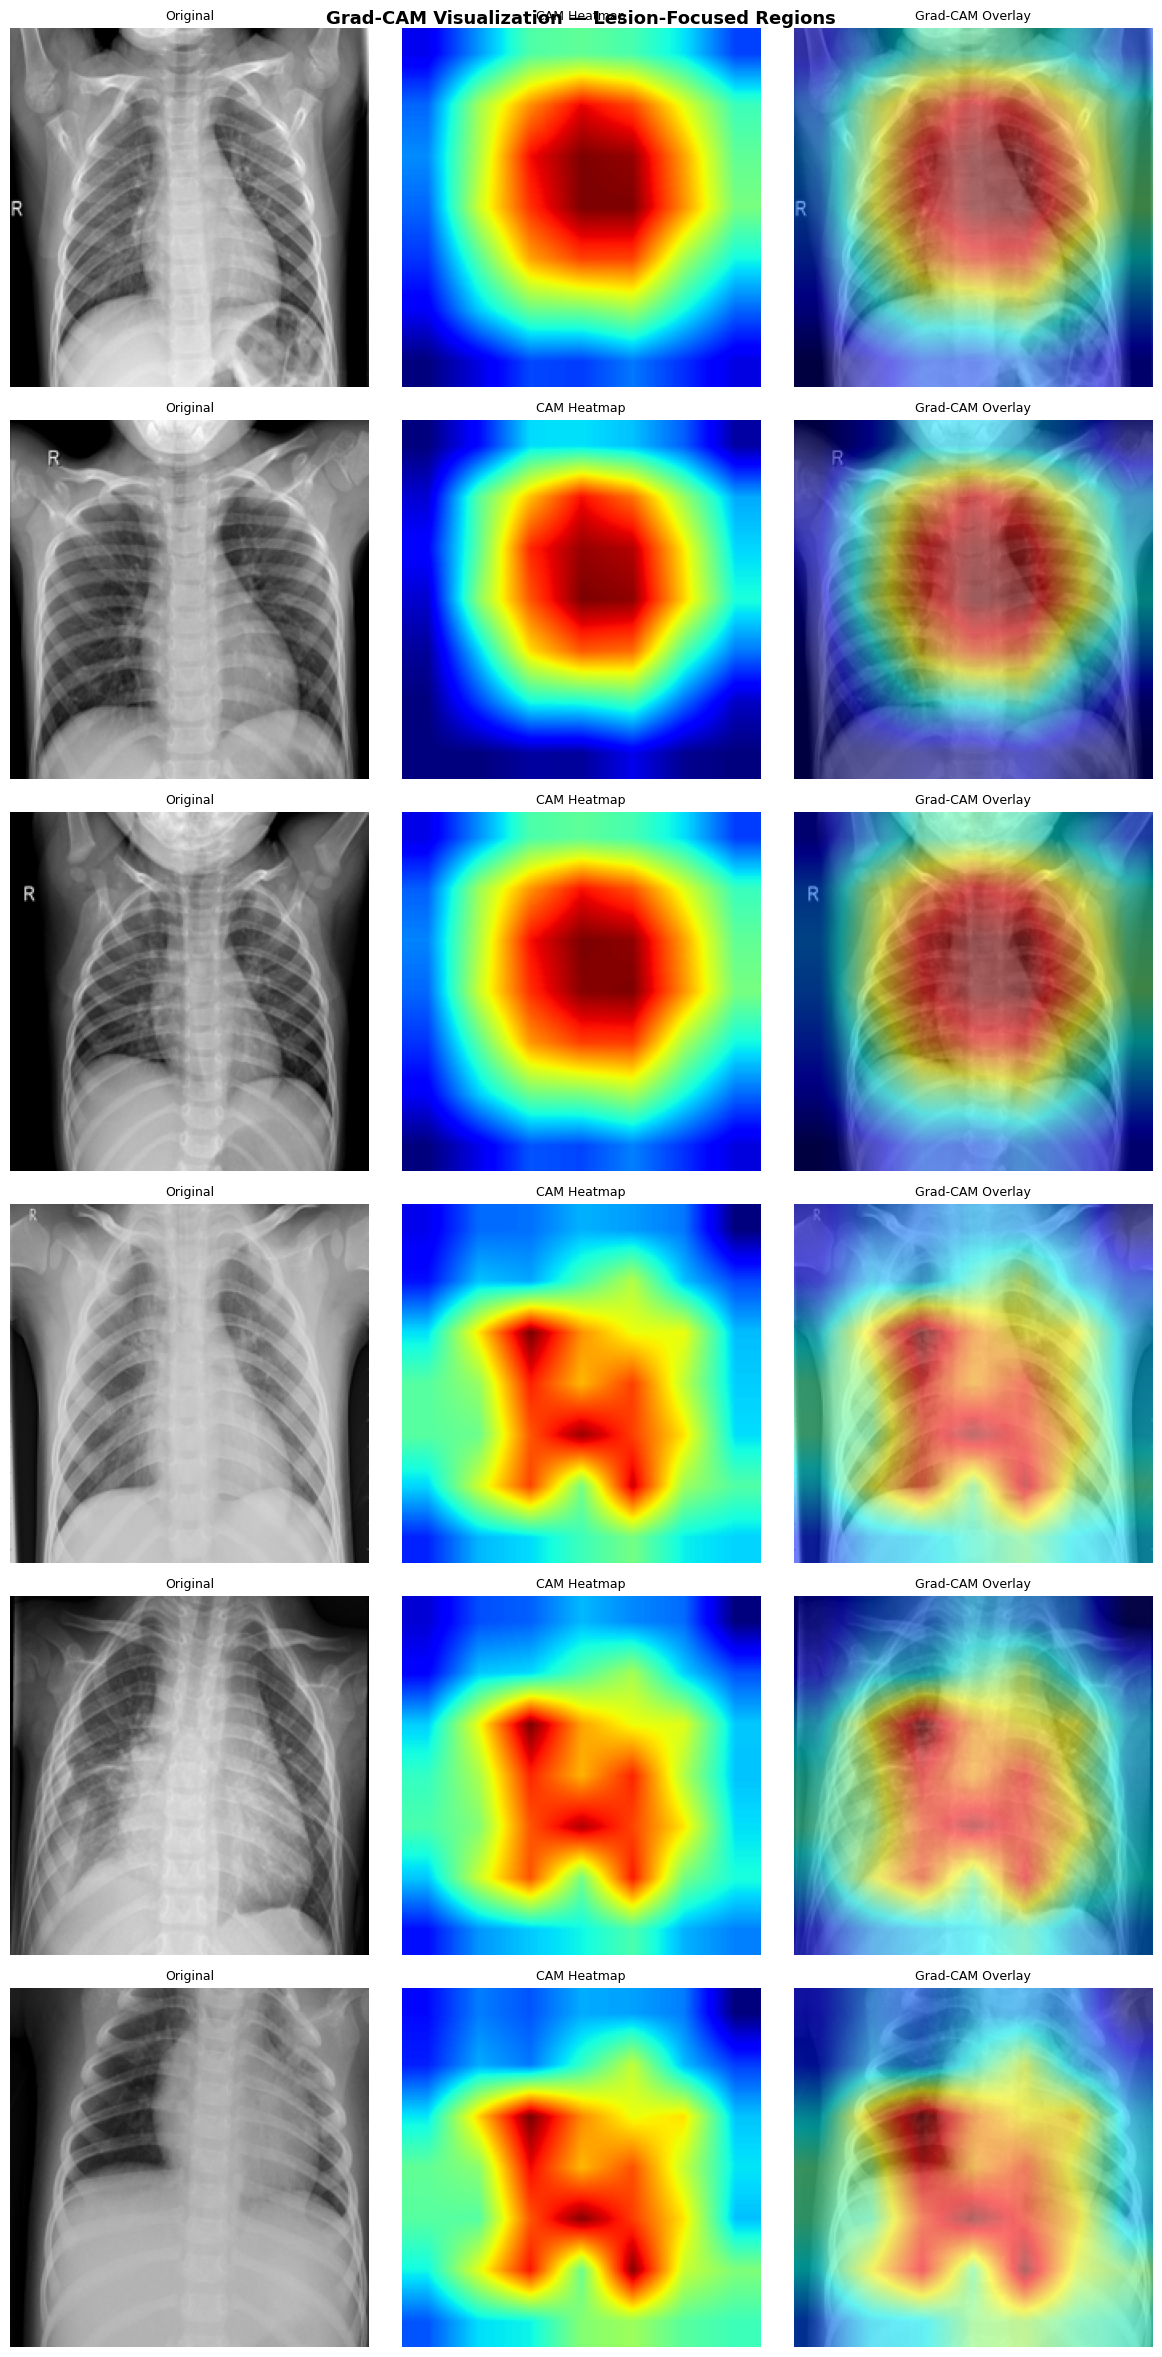

In [ ]:
# ── Grad-CAM target layer = last conv in LAMR branch3 (5×5 kernel) ────────────
# This highlights lesion-focused spatial regions.
target_layer = model.lamr.branch5[-2]   # the last BN before ReLU in branch5

# Fallback: use last conv of LAMR proj
try:
    _ = target_layer.weight
except AttributeError:
    target_layer = model.lamr.proj[0]   # Conv2d in proj

cam = GradCAM(model=model, target_layers=[target_layer])


def show_gradcam(img_path: Path, label: int, ax_row, transforms_fn):
    """Draw original + Grad-CAM overlay for one image."""
    img_np  = np.array(Image.open(img_path).convert('RGB'))
    img_t   = transforms_fn(image=img_np)['image'].unsqueeze(0).to(DEVICE)

    # Resize for display
    img_resized = np.array(Image.fromarray(img_np).resize((224, 224))) / 255.0

    # Grad-CAM
    targets = [ClassifierOutputTarget(label)]
    grayscale_cam = cam(input_tensor=img_t, targets=targets)[0]
    cam_img = show_cam_on_image(img_resized.astype(np.float32),
                                 grayscale_cam, use_rgb=True)

    ax_row[0].imshow(img_resized); ax_row[0].set_title('Original', fontsize=9)
    ax_row[1].imshow(grayscale_cam, cmap='jet');
    ax_row[1].set_title('CAM Heatmap', fontsize=9)
    ax_row[2].imshow(cam_img);    ax_row[2].set_title('Grad-CAM Overlay', fontsize=9)
    for a in ax_row:
        a.axis('off')


# ── Pick 3 random samples per class ──────────────────────────────────────────
n_samples = 3
fig, axes = plt.subplots(2 * n_samples, 3, figsize=(12, 4 * n_samples * 2))
fig.suptitle('Grad-CAM Visualization — Lesion-Focused Regions', fontsize=13, fontweight='bold')

val_tf = get_val_transforms()
row = 0
for cls_idx, cls_name in enumerate(cfg.CLASSES):
    cls_samples = [(p, l) for p, l in test_dataset.samples if l == cls_idx]
    chosen      = random.sample(cls_samples, min(n_samples, len(cls_samples)))
    for path, lbl in chosen:
        axes[row, 0].set_ylabel(cls_name, fontsize=10, fontweight='bold',
                                color='green' if cls_idx == 0 else 'red')
        show_gradcam(path, lbl, axes[row], val_tf)
        row += 1

plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_visualization.png', dpi=150)
plt.show()

## 16. Ablation Study — Effect of Removing LAMR and CBAF

The comparison table below (old §16) only compares *entire architectures* (Branch-1 alone, Branch-2 alone, Full Hybrid). It never isolates the contribution of the two components this framework actually adds on top of the backbones + ECA/CBAM: **CBAF** (attention-gated fusion, replacing naive concatenation) and **LAMR** (multi-scale lesion refinement).

This section runs a proper ablation: the *same* `HybridPneumoniaNet`, with one or more components switched off via the flags added above (`use_branch1`, `use_branch2`, `use_eca`, `use_cbam`, `use_cbaf`, `use_lamr`), trained and evaluated identically. It directly answers:

- **What happens if LAMR is removed?** compare rows with/without LAMR, holding CBAF fixed.
- **What happens if CBAF is removed?** compare rows with/without CBAF, holding LAMR fixed.
- Bonus: what happens if ECA / CBAM are removed from their branch, and how do the two branches perform alone?

> Each variant is trained for `cfg.ABLATION_EPOCHS` epochs (fewer than the main run) purely to keep the total ablation budget tractable — increase it if you have the compute for a tighter final table.


In [ ]:
# cell: full ablation-capable model — replaces BOTH old HybridPneumoniaNet defs
class HybridPneumoniaNet(nn.Module):
    def __init__(self, num_classes=2, proj_dim=256, lamr_channels=256, pretrained=True,
                 dropout_p=0.4, use_branch1=True, use_branch2=True,
                 use_eca=True, use_cbam=True, use_cbaf=True, use_lamr=True):
        super().__init__()
        self.use_branch1, self.use_branch2 = use_branch1, use_branch2
        self.use_cbaf, self.use_lamr, self.proj_dim = use_cbaf, use_lamr, proj_dim
        if not (use_branch1 or use_branch2):
            raise ValueError('At least one branch must be enabled.')
        if use_branch1:
            self.branch_shuffle = ShuffleNetV2_ECA(proj_dim=proj_dim, pretrained=pretrained, use_eca=use_eca)
        if use_branch2:
            self.branch_effnet = EfficientNetB0_CBAM(proj_dim=proj_dim, pretrained=pretrained, use_cbam=use_cbam)
        fused_dim = proj_dim * 2
        if use_cbaf:
            self.cbaf = CBAF(dim=proj_dim)
        self.fusion_proj = nn.Sequential(nn.Linear(fused_dim, lamr_channels), nn.BatchNorm1d(lamr_channels), nn.ReLU(inplace=True))
        self.upsample = nn.Sequential(nn.ConvTranspose2d(lamr_channels, lamr_channels, 7, 1, bias=False), nn.BatchNorm2d(lamr_channels), nn.ReLU(inplace=True))
        if use_lamr:
            self.lamr = LAMRBlock(in_channels=lamr_channels, out_channels=lamr_channels)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(dropout_p), nn.Linear(lamr_channels, lamr_channels // 2),
                                   nn.ReLU(inplace=True), nn.Dropout(dropout_p / 2), nn.Linear(lamr_channels // 2, num_classes))

    def forward(self, x):
        B = x.size(0)
        f1 = self.branch_shuffle(x) if self.use_branch1 else torch.zeros(B, self.proj_dim, device=x.device, dtype=x.dtype)
        f2 = self.branch_effnet(x) if self.use_branch2 else torch.zeros(B, self.proj_dim, device=x.device, dtype=x.dtype)
        fused = self.cbaf(f1, f2) if self.use_cbaf else torch.cat([f1, f2], dim=1)
        fused = self.fusion_proj(fused).unsqueeze(-1).unsqueeze(-1)
        fused = self.upsample(fused)
        if self.use_lamr:
            fused = self.lamr(fused)
        return self.head(self.gap(fused))

        # Your existing CBAF/LAMR modules should then
        # be conditionally applied in forward().

In [ ]:
# ── Ablation configurations ───────────────────────────────────────────────────
# Every entry is a full set of kwargs for HybridPneumoniaNet. Keeping every
# other flag fixed while flipping exactly one (or a clearly-labelled pair)
# is what turns this into a real ablation rather than a model zoo.
ABLATION_CONFIGS = {
    # -- Single branches alone (sanity baselines) --------------------------
    'Branch-1 only: ShuffleNetV2+ECA': dict(
        use_branch1=True,  use_branch2=False,
        use_eca=True, use_cbam=True, use_cbaf=False, use_lamr=False),
    'Branch-2 only: EfficientNet-B0+CBAM': dict(
        use_branch1=False, use_branch2=True,
        use_eca=True, use_cbam=True, use_cbaf=False, use_lamr=False),

    # -- Core ablation grid: CBAF x LAMR (2x2) ------------------------------
    'Hybrid: naive concat, no LAMR (both removed)': dict(
        use_branch1=True, use_branch2=True,
        use_eca=True, use_cbam=True, use_cbaf=False, use_lamr=False),
    'Hybrid: + CBAF only (no LAMR)': dict(
        use_branch1=True, use_branch2=True,
        use_eca=True, use_cbam=True, use_cbaf=True,  use_lamr=False),
    'Hybrid: + LAMR only (no CBAF)': dict(
        use_branch1=True, use_branch2=True,
        use_eca=True, use_cbam=True, use_cbaf=False, use_lamr=True),
    'Full Hybrid: CBAF + LAMR (proposed)': dict(
        use_branch1=True, use_branch2=True,
        use_eca=True, use_cbam=True, use_cbaf=True,  use_lamr=True),

    # -- Bonus: branch-level attention ablation (ECA / CBAM) ----------------
    'Full Hybrid, w/o ECA (branch-1 attention removed)': dict(
        use_branch1=True, use_branch2=True,
        use_eca=False, use_cbam=True, use_cbaf=True, use_lamr=True),
    'Full Hybrid, w/o CBAM (branch-2 attention removed)': dict(
        use_branch1=True, use_branch2=True,
        use_eca=True, use_cbam=False, use_cbaf=True, use_lamr=True),
}

for name in ABLATION_CONFIGS:
    print(' -', name)
print(f'\n{len(ABLATION_CONFIGS)} ablation configurations queued.')


 - Branch-1 only: ShuffleNetV2+ECA
 - Branch-2 only: EfficientNet-B0+CBAM
 - Hybrid: naive concat, no LAMR (both removed)
 - Hybrid: + CBAF only (no LAMR)
 - Hybrid: + LAMR only (no CBAF)
 - Full Hybrid: CBAF + LAMR (proposed)
 - Full Hybrid, w/o ECA (branch-1 attention removed)
 - Full Hybrid, w/o CBAM (branch-2 attention removed)

8 ablation configurations queued.


In [ ]:
def run_ablation_experiment(name: str, model_kwargs: dict, epochs: int = None):
    """
    Build, train, and evaluate ONE ablation variant of HybridPneumoniaNet.
    Reuses the exact same train_one_epoch / validate / predict functions
    used for the main model, so results are directly comparable.
    """
    epochs = epochs or cfg.ABLATION_EPOCHS
    print(f'\n{"=" * 78}\n Ablation run: {name}\n{"=" * 78}')

    m = HybridPneumoniaNet(
        num_classes   = cfg.NUM_CLASSES,
        proj_dim      = cfg.FUSION_DIM,
        lamr_channels = cfg.LAMR_CHANNELS,
        pretrained    = True,
        **model_kwargs
    ).to(DEVICE)

    opt   = optim.AdamW(m.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sch   = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=max(epochs // 2, 1), T_mult=2, eta_min=1e-6)
    scal  = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))
    crit  = nn.CrossEntropyLoss(weight=class_weights)

    best_auc, best_state = 0.0, None
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc          = train_one_epoch(m, train_loader, opt, crit, scal, DEVICE)
        va_loss, va_acc, va_auc  = validate(m, val_loader, crit, DEVICE)
        sch.step()
        print(f'  epoch {ep:02d}/{epochs}  '
              f'train_acc={tr_acc:.3f}  val_acc={va_acc:.3f}  val_auc={va_auc:.3f}')
        if va_auc > best_auc:
            best_auc   = va_auc
            best_state = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}

    if best_state is not None:
        m.load_state_dict(best_state)
    m.eval()

    y_pred_a, y_prob_a, y_true_a = predict(m, test_loader, DEVICE)
    n_params = sum(p.numel() for p in m.parameters()) / 1e6

    result = {
        'Configuration' : name,
        'Params (M)'    : round(n_params, 2),
        'Accuracy (%)'  : round(accuracy_score(y_true_a, y_pred_a) * 100, 2),
        'Precision'     : round(precision_score(y_true_a, y_pred_a), 4),
        'Recall'        : round(recall_score(y_true_a, y_pred_a), 4),
        'F1-Score'      : round(f1_score(y_true_a, y_pred_a), 4),
        'AUC-ROC'       : round(roc_auc_score(y_true_a, y_prob_a), 4),
    }

    del m
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    return result


print('Ablation training/eval routine defined.')


Ablation training/eval routine defined.


In [ ]:
# ── Run every ablation configuration ──────────────────────────────────────────
# NOTE: this trains len(ABLATION_CONFIGS) models from scratch. On a single GPU
# with cfg.ABLATION_EPOCHS=10 this is the dominant cost of the whole notebook —
# lower ABLATION_EPOCHS (or the number of configs) if you're compute-constrained.
ablation_results = []
for name, kwargs in ABLATION_CONFIGS.items():
    result = run_ablation_experiment(name, kwargs)
    ablation_results.append(result)
    print(f'  -> {name}: Acc={result["Accuracy (%)"]:.2f}%  '
          f'F1={result["F1-Score"]:.4f}  AUC={result["AUC-ROC"]:.4f}')

print('\nAll ablation runs complete.')



 Ablation run: Branch-1 only: ShuffleNetV2+ECA


  Train:   0%|          | 0/128 [00:00<?, ?it/s]

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

  epoch 01/10  train_acc=0.832  val_acc=0.957  val_auc=0.987


  Train:   0%|          | 0/128 [00:00<?, ?it/s]

...

  Train:   0%|          | 0/128 [00:00<?, ?it/s]

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

  epoch 10/10  train_acc=0.957  val_acc=0.954  val_auc=0.997


  Test:   0%|          | 0/28 [00:00<?, ?it/s]

  -> Full Hybrid, w/o CBAM (branch-2 attention removed): Acc=97.38%  F1=0.9820  AUC=0.9970

All ablation runs complete.


In [ ]:
# ── Assemble the ablation results table ───────────────────────────────────────
ablation_df = pd.DataFrame(ablation_results)
ablation_df = ablation_df.set_index('Configuration').loc[list(ABLATION_CONFIGS.keys())].reset_index()
display(ablation_df)
ablation_df.to_csv('/kaggle/working/ablation_study.csv', index=False)
print('Ablation table saved -> /kaggle/working/ablation_study.csv')


,Configuration,Params (M),Accuracy (%),Precision,Recall,F1-Score,AUC-ROC
0,Branch-1 only: ShuffleNetV2+ECA,4.89,97.27,0.9858,0.9766,0.9812,0.9956
1,Branch-2 only: EfficientNet-B0+CBAM,7.92,95.68,0.9935,0.9470,0.9696,0.9964
2,"Hybrid: naive concat, no LAMR (both removed)",9.43,97.72,0.9844,0.9844,0.9844,0.9960
3,Hybrid: + CBAF only (no LAMR),9.53,96.81,0.9952,0.9610,0.9778,0.9966
4,Hybrid: + LAMR only (no CBAF),9.74,97.38,0.9889,0.9750,0.9819,0.9971
5,Full Hybrid: CBAF + LAMR (proposed),9.84,97.27,0.9905,0.9719,0.9811,0.9975
6,"Full Hybrid, w/o ECA (branch-1 attention removed)",9.84,97.38,0.9798,0.9844,0.9821,0.9969
7,"Full Hybrid, w/o CBAM (branch-2 attention remo...",9.63,97.38,0.9843,0.9797,0.9820,0.9970


Ablation table saved -> /kaggle/working/ablation_study.csv


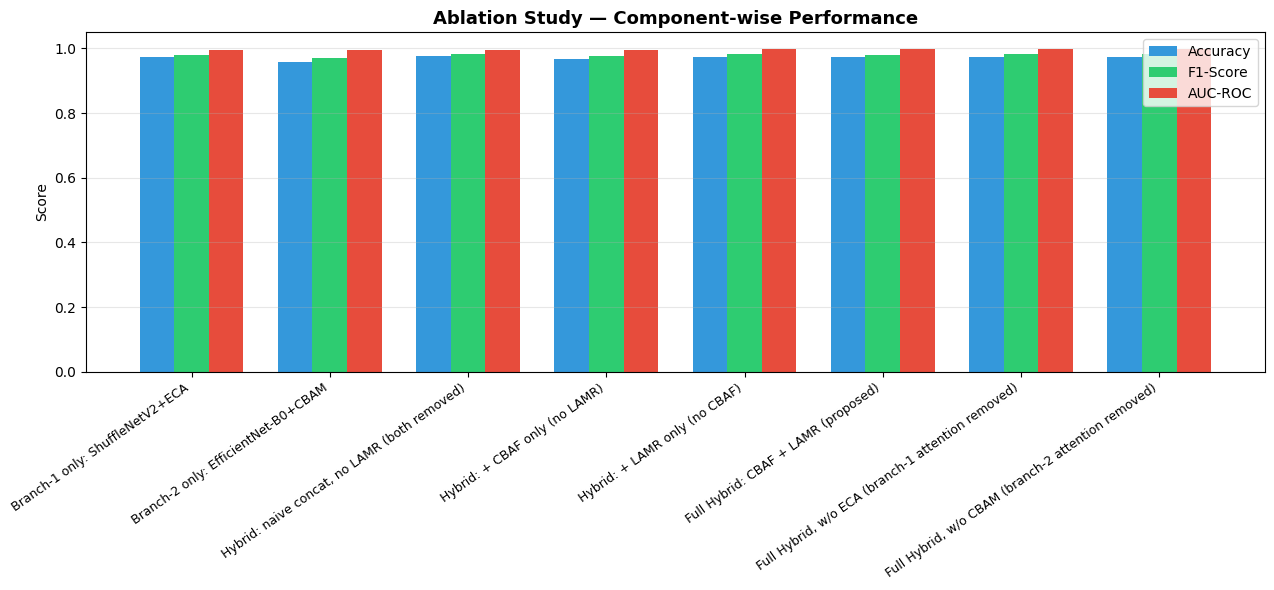

In [ ]:
# ── Visualize: Accuracy / F1 / AUC across every ablation configuration ───────
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(ablation_df))
width = 0.25

ax.bar(x - width, ablation_df['Accuracy (%)'] / 100, width, label='Accuracy', color='#3498db')
ax.bar(x,          ablation_df['F1-Score'],          width, label='F1-Score', color='#2ecc71')
ax.bar(x + width,  ablation_df['AUC-ROC'],           width, label='AUC-ROC',  color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(ablation_df['Configuration'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Ablation Study — Component-wise Performance', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/ablation_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Isolate the marginal effect of each component ────────────────────────────
def _get(name, col):
    return ablation_df.loc[ablation_df['Configuration'] == name, col].values[0]

# (label, config_WITH_component, config_WITHOUT_component)
ablation_pairs = [
    ('Removing LAMR  (CBAF present)',
     'Full Hybrid: CBAF + LAMR (proposed)', 'Hybrid: + CBAF only (no LAMR)'),
    ('Removing LAMR  (CBAF absent)',
     'Hybrid: + LAMR only (no CBAF)',       'Hybrid: naive concat, no LAMR (both removed)'),
    ('Removing CBAF  (LAMR present)',
     'Full Hybrid: CBAF + LAMR (proposed)', 'Hybrid: + LAMR only (no CBAF)'),
    ('Removing CBAF  (LAMR absent)',
     'Hybrid: + CBAF only (no LAMR)',       'Hybrid: naive concat, no LAMR (both removed)'),
    ('Removing ECA   (branch-1 attention)',
     'Full Hybrid: CBAF + LAMR (proposed)', 'Full Hybrid, w/o ECA (branch-1 attention removed)'),
    ('Removing CBAM  (branch-2 attention)',
     'Full Hybrid: CBAF + LAMR (proposed)', 'Full Hybrid, w/o CBAM (branch-2 attention removed)'),
]

metric_cols = ['Accuracy (%)', 'F1-Score', 'AUC-ROC']
delta_records = []
for label, with_name, without_name in ablation_pairs:
    row = {'Component removed': label,
           'With component'   : with_name,
           'Without component': without_name}
    for m_col in metric_cols:
        row[f'Δ {m_col}'] = round(_get(with_name, m_col) - _get(without_name, m_col), 4)
    delta_records.append(row)

delta_df = pd.DataFrame(delta_records)
display(delta_df)
delta_df.to_csv('/kaggle/working/ablation_deltas.csv', index=False)
print('Ablation deltas saved -> /kaggle/working/ablation_deltas.csv')
print('\nPositive Δ means the component HELPED; negative Δ means removing it actually helped.')


,Component removed,With component,Without component,Δ Accuracy (%),Δ F1-Score,Δ AUC-ROC
0,Removing LAMR (CBAF present),Full Hybrid: CBAF + LAMR (proposed),Hybrid: + CBAF only (no LAMR),0.46,0.0033,0.0009
1,Removing LAMR (CBAF absent),Hybrid: + LAMR only (no CBAF),"Hybrid: naive concat, no LAMR (both removed)",-0.34,-0.0025,0.0011
2,Removing CBAF (LAMR present),Full Hybrid: CBAF + LAMR (proposed),Hybrid: + LAMR only (no CBAF),-0.11,-0.0008,0.0004
3,Removing CBAF (LAMR absent),Hybrid: + CBAF only (no LAMR),"Hybrid: naive concat, no LAMR (both removed)",-0.91,-0.0066,0.0006
4,Removing ECA (branch-1 attention),Full Hybrid: CBAF + LAMR (proposed),"Full Hybrid, w/o ECA (branch-1 attention removed)",-0.11,-0.0010,0.0006
5,Removing CBAM (branch-2 attention),Full Hybrid: CBAF + LAMR (proposed),"Full Hybrid, w/o CBAM (branch-2 attention remo...",-0.11,-0.0009,0.0005


Ablation deltas saved -> /kaggle/working/ablation_deltas.csv

Positive Δ means the component HELPED; negative Δ means removing it actually helped.


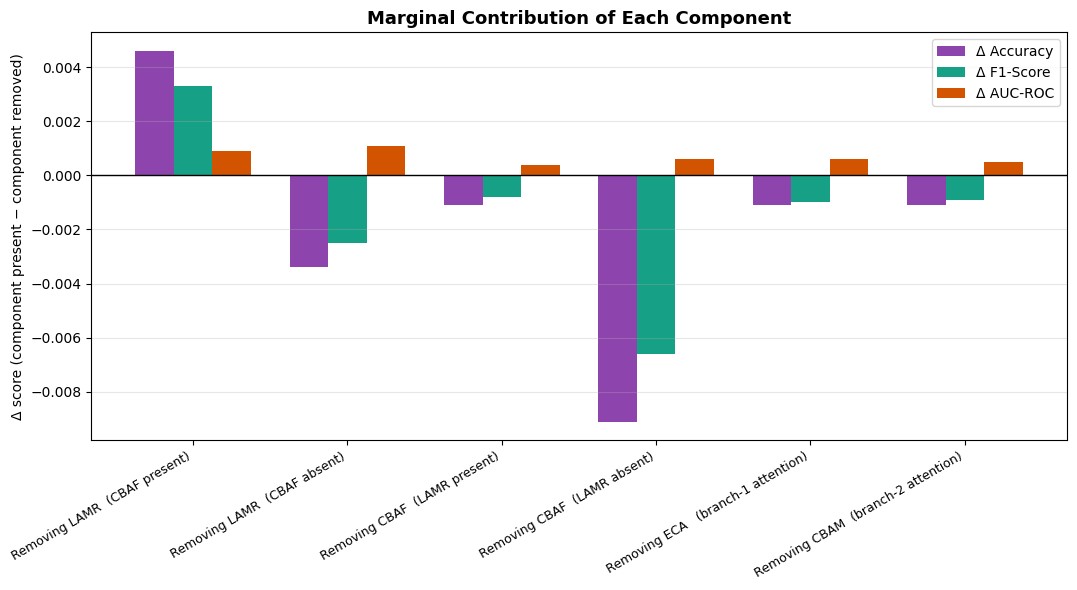

In [ ]:
# ── Visualize the marginal contribution of LAMR / CBAF / ECA / CBAM ──────────
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(delta_df))
width = 0.25

ax.bar(x - width, delta_df['Δ Accuracy (%)'] / 100, width, label='Δ Accuracy', color='#8e44ad')
ax.bar(x,          delta_df['Δ F1-Score'],           width, label='Δ F1-Score', color='#16a085')
ax.bar(x + width,  delta_df['Δ AUC-ROC'],            width, label='Δ AUC-ROC',  color='#d35400')

ax.axhline(0, color='black', lw=1)
ax.set_xticks(x)
ax.set_xticklabels(delta_df['Component removed'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Δ score (component present − component removed)')
ax.set_title('Marginal Contribution of Each Component', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/ablation_delta_chart.png', dpi=150, bbox_inches='tight')
plt.show()


## 19. Architecture Diagram (Text Summary)

In [ ]:
from torchinfo import summary

# Install torchinfo if needed
try:
    from torchinfo import summary
except ImportError:
    pip_install('torchinfo')
    from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224),
        col_names=['input_size', 'output_size', 'num_params', 'mult_adds'],
        depth=3)

Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Mult-Adds
HybridPneumoniaNet                                           [1, 3, 224, 224]          [1, 2]                    --                        --
├─ShuffleNetV2_ECA: 1-1                                      [1, 3, 224, 224]          [1, 256]                  --                        --
│    └─Sequential: 2-1                                       [1, 3, 224, 224]          [1, 1024, 7, 7]           --                        --
│    │    └─Sequential: 3-1                                  [1, 3, 224, 224]          [1, 24, 112, 112]         696                       8,128,560
│    │    └─MaxPool2d: 3-2                                   [1, 24, 112, 112]         [1, 24, 56, 56]           --                        --
│    │    └─Sequential: 3-3                                  [1, 24, 56, 56]           [1, 116, 28, 28]          30,192               

## 20. Save Outputs

In [ ]:
# ── Save final predictions ────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'true_label'     : y_true,
    'predicted_label': y_pred,
    'prob_pneumonia'  : y_prob,
    'class_true'     : [cfg.CLASSES[l] for l in y_true],
    'class_pred'     : [cfg.CLASSES[l] for l in y_pred],
    'correct'        : y_true == y_pred
})
results_df.to_csv('/kaggle/working/test_predictions.csv', index=False)

# ── Save metrics summary ──────────────────────────────────────────────────────
metrics_df = pd.DataFrame([{
    'Accuracy' : round(acc, 4),
    'Precision': round(prec, 4),
    'Recall'   : round(rec, 4),
    'F1-Score' : round(f1, 4),
    'AUC-ROC'  : round(auc, 4)
}])
metrics_df.to_csv('/kaggle/working/metrics_summary.csv', index=False)

print('All outputs saved to /kaggle/working/')
print('\nFiles:')
for f in sorted(Path('/kaggle/working/').glob('*')):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} KB)')

All outputs saved to /kaggle/working/

Files:
  .virtual_documents  (4.0 KB)
  ablation_bar_chart.png  (138.8 KB)
  ablation_delta_chart.png  (100.6 KB)
  ablation_deltas.csv  (0.8 KB)
  ablation_study.csv  (0.7 KB)
  best_model.pth  (38564.0 KB)
  chest_xray_split  (4.0 KB)
  comparison_table.csv  (0.4 KB)
  confusion_matrix.png  (64.7 KB)
  gradcam_visualization.png  (3265.0 KB)
  metrics_summary.csv  (0.1 KB)
  performance_gap_heatmap.png  (59.8 KB)
  radar_chart.png  (127.7 KB)
  roc_curve.png  (71.1 KB)
  sample_images.png  (1095.3 KB)
  test_predictions.csv  (33.1 KB)
  training_curves.png  (173.2 KB)


---
## Summary

| Component | Original Paper | This Update |
|-----------|---------------|-------------|
| Branch 1 | VGG16 | **ShuffleNetV2 + ECA** |
| Branch 2 | ResNet | **EfficientNet-B0 + CBAM** |
| Fusion strategy | — | **CBAF (cross-branch attention-gated fusion)** |
| Multi-scale module | — | **LAMR (1×1, 3×3, 5×5 parallel convs)** |
| Dimensionality reduction | PCA (100 components) | End-to-end via projection + pooling |
| Classifier | SVM / Random Forest | Fully-connected + Softmax |
| Interpretability | None | **Grad-CAM** |
| Parameters | ~140M+ | **~10–15M (lightweight)** |

**Key improvements:**
- ECA provides parameter-free channel attention that adaptively scales features with minimal overhead
- CBAM in EfficientNet-B0 adds channel + spatial attention jointly for discriminative global features
- LAMR module mirrors the HPFF + GCSAM multi-scale lesion awareness from nodule detection literature
- Grad-CAM provides visual explanations aligned with clinically relevant lung regions

In [ ]:
# ── Ablation configurations ───────────────────────────────────────────────────
# Every entry is a full set of kwargs for HybridPneumoniaNet. Keeping every
# other flag fixed while flipping exactly one (or a clearly-labelled pair)
# is what turns this into a real ablation rather than a model zoo.
ABLATION_CONFIGS = {
    # -- Single branches alone (sanity baselines) --------------------------
    'Branch-1 only: ShuffleNetV2+ECA': dict(
        use_branch1=True,  use_branch2=False,
        use_eca=True, use_cbam=True, use_cbaf=False, use_lamr=False),
    'Branch-2 only: EfficientNet-B0+CBAM': dict(
        use_branch1=False, use_branch2=True,
        use_eca=True, use_cbam=True, use_cbaf=False, use_lamr=False),

    # -- Core ablation grid: CBAF x LAMR (2x2) ------------------------------
    'Hybrid: naive concat, no LAMR (both removed)': dict(
        use_branch1=True, use_branch2=True,
        use_eca=True, use_cbam=True, use_cbaf=False, use_lamr=False),
    'Hybrid: + CBAF only (no LAMR)': dict(
        use_branch1=True, use_branch2=True,
        use_eca=True, use_cbam=True, use_cbaf=True,  use_lamr=False),
    'Hybrid: + LAMR only (no CBAF)': dict(
        use_branch1=True, use_branch2=True,
        use_eca=True, use_cbam=True, use_cbaf=False, use_lamr=True),
    'Full Hybrid: CBAF + LAMR (proposed)': dict(
        use_branch1=True, use_branch2=True,
        use_eca=True, use_cbam=True, use_cbaf=True,  use_lamr=True),

    # -- Bonus: branch-level attention ablation (ECA / CBAM) ----------------
    'Full Hybrid, w/o ECA (branch-1 attention removed)': dict(
        use_branch1=True, use_branch2=True,
        use_eca=False, use_cbam=True, use_cbaf=True, use_lamr=True),
    'Full Hybrid, w/o CBAM (branch-2 attention removed)': dict(
        use_branch1=True, use_branch2=True,
        use_eca=True, use_cbam=False, use_cbaf=True, use_lamr=True),
}

for name in ABLATION_CONFIGS:
    print(' -', name)
print(f'\n{len(ABLATION_CONFIGS)} ablation configurations queued.')


 - Branch-1 only: ShuffleNetV2+ECA
 - Branch-2 only: EfficientNet-B0+CBAM
 - Hybrid: naive concat, no LAMR (both removed)
 - Hybrid: + CBAF only (no LAMR)
 - Hybrid: + LAMR only (no CBAF)
 - Full Hybrid: CBAF + LAMR (proposed)
 - Full Hybrid, w/o ECA (branch-1 attention removed)
 - Full Hybrid, w/o CBAM (branch-2 attention removed)

8 ablation configurations queued.


In [ ]:
def run_ablation_experiment(name: str, model_kwargs: dict, epochs: int = None):
    """
    Build, train, and evaluate ONE ablation variant of HybridPneumoniaNet.
    Reuses the exact same train_one_epoch / validate / predict functions
    used for the main model, so results are directly comparable.
    """
    epochs = epochs or cfg.ABLATION_EPOCHS
    print(f'\n{"=" * 78}\n Ablation run: {name}\n{"=" * 78}')

    m = HybridPneumoniaNet(
        num_classes   = cfg.NUM_CLASSES,
        proj_dim      = cfg.FUSION_DIM,
        lamr_channels = cfg.LAMR_CHANNELS,
        pretrained    = True,
        **model_kwargs
    ).to(DEVICE)

    opt   = optim.AdamW(m.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sch   = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=max(epochs // 2, 1), T_mult=2, eta_min=1e-6)
    scal  = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))
    crit  = nn.CrossEntropyLoss(weight=class_weights)

    best_auc, best_state = 0.0, None
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc          = train_one_epoch(m, train_loader, opt, crit, scal, DEVICE)
        va_loss, va_acc, va_auc  = validate(m, val_loader, crit, DEVICE)
        sch.step()
        print(f'  epoch {ep:02d}/{epochs}  '
              f'train_acc={tr_acc:.3f}  val_acc={va_acc:.3f}  val_auc={va_auc:.3f}')
        if va_auc > best_auc:
            best_auc   = va_auc
            best_state = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}

    if best_state is not None:
        m.load_state_dict(best_state)
    m.eval()

    y_pred_a, y_prob_a, y_true_a = predict(m, test_loader, DEVICE)
    n_params = sum(p.numel() for p in m.parameters()) / 1e6

    result = {
        'Configuration' : name,
        'Params (M)'    : round(n_params, 2),
        'Accuracy (%)'  : round(accuracy_score(y_true_a, y_pred_a) * 100, 2),
        'Precision'     : round(precision_score(y_true_a, y_pred_a), 4),
        'Recall'        : round(recall_score(y_true_a, y_pred_a), 4),
        'F1-Score'      : round(f1_score(y_true_a, y_pred_a), 4),
        'AUC-ROC'       : round(roc_auc_score(y_true_a, y_prob_a), 4),
    }

    del m
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    return result


print('Ablation training/eval routine defined.')


Ablation training/eval routine defined.


In [ ]:
# ── Run every ablation configuration ──────────────────────────────────────────
# NOTE: this trains len(ABLATION_CONFIGS) models from scratch. On a single GPU
# with cfg.ABLATION_EPOCHS=10 this is the dominant cost of the whole notebook —
# lower ABLATION_EPOCHS (or the number of configs) if you're compute-constrained.
ablation_results = []
for name, kwargs in ABLATION_CONFIGS.items():
    result = run_ablation_experiment(name, kwargs)
    ablation_results.append(result)
    print(f'  -> {name}: Acc={result["Accuracy (%)"]:.2f}%  '
          f'F1={result["F1-Score"]:.4f}  AUC={result["AUC-ROC"]:.4f}')

print('\nAll ablation runs complete.')



 Ablation run: Branch-1 only: ShuffleNetV2+ECA


  Train:   0%|          | 0/128 [00:00<?, ?it/s]

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

  epoch 01/10  train_acc=0.816  val_acc=0.874  val_auc=0.991


  Train:   0%|          | 0/128 [00:00<?, ?it/s]

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

KeyboardInterrupt: 